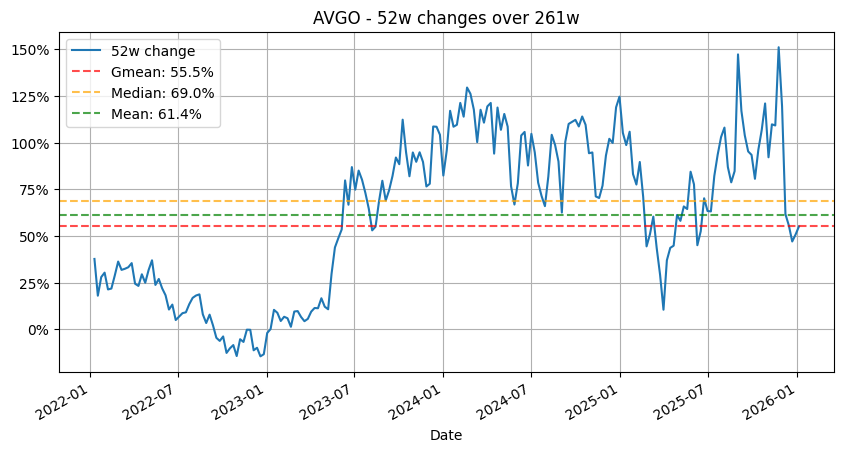

In [4]:
from yfetch import get_stock_history
from scipy.stats import gmean
import matplotlib.pyplot as plt

symbol = 'AVGO'
weeks = 52
history = get_stock_history(symbol, period='5y', interval='1wk', cache_days=2)
history_weeks = len(history)
changes = history.Close.pct_change(periods=weeks).dropna()
gmean_change = gmean(1 + changes) - 1 # geometric mean of changes
median_change = changes.median()
mean_change = changes.mean()

ax = changes.plot(title=f'{symbol} - {weeks}w changes over {history_weeks}w', figsize=(10, 5), grid=True, label=f'{weeks}w change')
ax.axhline(y=gmean_change, color='red', linestyle='--', alpha=0.7, label=f'Gmean: {gmean_change:.1%}')
ax.axhline(y=median_change, color='orange', linestyle='--', alpha=0.7, label=f'Median: {median_change:.1%}')
ax.axhline(y=mean_change, color='green', linestyle='--', alpha=0.7, label=f'Mean: {mean_change:.1%}')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.legend()